步骤1：1D高斯ULA采样


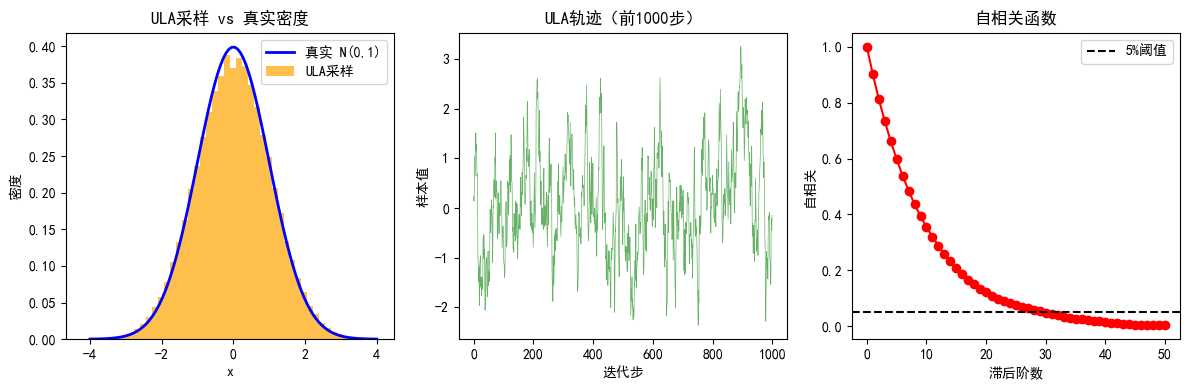

采样方差: 1.0717
理论方差: 1.0526
采样均值: 0.0043
理论均值: 0.0000

步骤2：步长敏感性分析


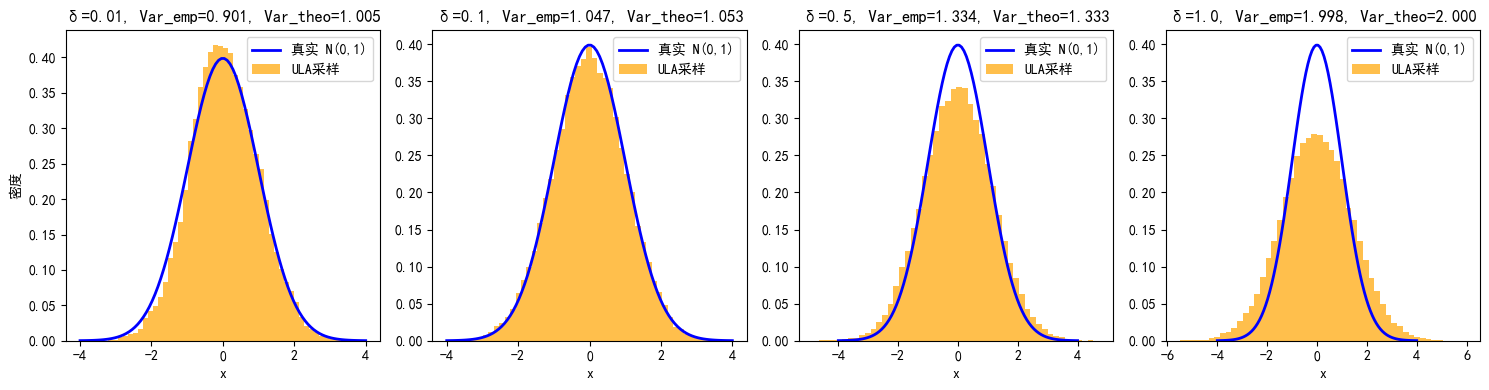

步长敏感性总结：
  δ=1.0 时，理论方差为∞（不稳定），实际采样会发散
  小δ（如0.01）方差更接近1，但收敛慢
  存在偏差-方差权衡：δ小→偏差小但收敛慢；δ大→偏差大但收敛快

步骤3：2D高斯混合ULA采样与得分场可视化


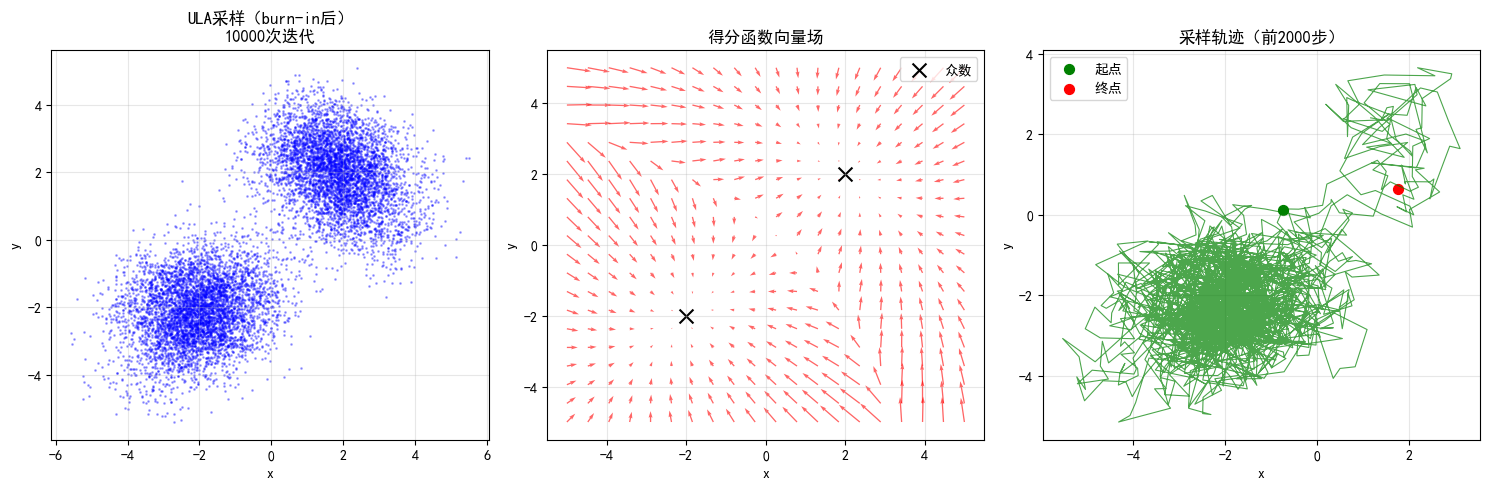


实验5.1 总结
1. ULA与Langevin SDE的关系：ULA是Langevin SDE的Euler-Maruyama离散化
   步长δ越小，近似越精确
2. 收敛性：在小步长且目标分布强对数凹时，ULA样本分布收敛到真实目标分布
3. 偏差-方差权衡：离散化引入误差，可通过调整δ平衡近似精度与计算效率
4. 得分函数的几何含义：得分函数是概率分布的'方向场'
   Langevin动力学沿此向量场流动


In [2]:
"""
实验5.1 Langevin SDE推导与数值验证
对应章节：5.1（从离散ULA到连续Langevin SDE）
素材来源：Mathematics.../Teaching Unit 2/labs/lab1_ULA_sol.ipynb
  - ULA_gauss() 函数
  - var_compare() 函数
  - 1D实验代码（ULA直方图 vs 真实密度）
原创设计：2D高斯混合得分场可视化

实验内容：
  步骤1：1D高斯ULA采样，验证收敛到目标分布
  步骤2：步长敏感性分析（偏差-方差权衡）
  步骤3：2D高斯混合ULA采样与得分场可视化
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# ULA_gauss 函数（取自 lab1_ULA_sol.ipynb）
# 从1D标准高斯 N(0,1) 中用ULA采样
# 势能 U(x)=x²/2, ∇U(x)=x
# ULA: X_{m+1} = X_m - δ·∇U(X_m) + √(2δ)·Z_{m+1}
#                  = (1-δ)·X_m + √(2δ)·Z_{m+1}
# ============================================================
def ULA_gauss(niter, delta, x0=0):
    """
    ULA采样标准高斯分布 N(0,1)
    势能 U(x) = -log p(x) = x^2/2
    梯度 ∇U(x) = x
    """
    Y = np.zeros(niter,)
    X = x0
    for i in range(niter):
        Z = np.random.randn()
        grad = X  # ∇U(x) = x 对于标准高斯
        X = X - delta * grad + np.sqrt(2 * delta) * Z
        Y[i] = X
    return Y


# ============================================================
# 步骤1：1D高斯ULA采样（回顾第4章，增加自相关分析）
# ============================================================
print("=" * 60)
print("步骤1：1D高斯ULA采样")
print("=" * 60)

niter = 100000
delta = 0.1
x0 = 0

# 运行ULA
samples = ULA_gauss(niter, delta, x0)

# 可视化
plt.figure(figsize=(12, 4))

# 直方图 vs 真实密度
plt.subplot(1, 3, 1)
x = np.linspace(-4, 4, 100)
true_density = 1/np.sqrt(2*np.pi) * np.exp(-x**2 / 2)
plt.plot(x, true_density, 'b-', lw=2, label='真实 N(0,1)')
plt.hist(samples, bins=50, density=True, alpha=0.7, color='orange', label='ULA采样')
plt.xlabel('x')
plt.ylabel('密度')
plt.title('ULA采样 vs 真实密度')
plt.legend()

# 轨迹图
plt.subplot(1, 3, 2)
plt.plot(samples[:1000], 'g-', alpha=0.6, lw=0.5)
plt.xlabel('迭代步')
plt.ylabel('样本值')
plt.title('ULA轨迹（前1000步）')

# 自相关函数（纯numpy实现，无需statsmodels）
def compute_acf(x, nlags=50):
    x = x - np.mean(x)
    n = len(x)
    acf_vals = np.zeros(nlags + 1)
    for lag in range(nlags + 1):
        acf_vals[lag] = np.sum(x[:n-lag] * x[lag:]) / (n * np.var(x))
    return acf_vals
acf_values = compute_acf(samples, nlags=50)
plt.subplot(1, 3, 3)
plt.plot(acf_values, 'r-o')
plt.xlabel('滞后阶数')
plt.ylabel('自相关')
plt.title('自相关函数')
plt.axhline(y=0.05, color='k', linestyle='--', label='5%阈值')
plt.legend()

plt.tight_layout()
plt.savefig('步骤1_ULA采样验证.png', dpi=150)
plt.show()

# 计算统计量
print(f"采样方差: {np.var(samples):.4f}")
print(f"理论方差: {2/(2-delta):.4f}")  # 2/(2-δ)是ULA的理论方差
print(f"采样均值: {np.mean(samples):.4f}")
print(f"理论均值: {0:.4f}")


# ============================================================
# 步骤2：步长敏感性分析
# ============================================================
print("\n" + "=" * 60)
print("步骤2：步长敏感性分析")
print("=" * 60)

deltas = [0.01, 0.1, 0.5, 1.0]
niter = 50000

plt.figure(figsize=(15, 4))

for i, delta in enumerate(deltas):
    samples = ULA_gauss(niter, delta, x0=0)
    empirical_var = np.var(samples)
    theoretical_var = 2 / (2 - delta)

    plt.subplot(1, len(deltas), i+1)
    x = np.linspace(-4, 4, 100)
    true_density = 1/np.sqrt(2*np.pi) * np.exp(-x**2 / 2)
    plt.plot(x, true_density, 'b-', lw=2, label='真实 N(0,1)')
    plt.hist(samples, bins=50, density=True, alpha=0.7,
             color='orange', label='ULA采样')
    plt.title(f'δ={delta}, Var_emp={empirical_var:.3f}, Var_theo={theoretical_var:.3f}')
    plt.xlabel('x')
    if i == 0:
        plt.ylabel('密度')
    plt.legend()

plt.tight_layout()
plt.savefig('步骤2_步长敏感性.png', dpi=150)
plt.show()

print("步长敏感性总结：")
print("  δ=1.0 时，理论方差为∞（不稳定），实际采样会发散")
print("  小δ（如0.01）方差更接近1，但收敛慢")
print("  存在偏差-方差权衡：δ小→偏差小但收敛慢；δ大→偏差大但收敛快")


# ============================================================
# 步骤3：2D高斯混合分布与得分场可视化（原创设计）
# ============================================================
print("\n" + "=" * 60)
print("步骤3：2D高斯混合ULA采样与得分场可视化")
print("=" * 60)

def gaussian_mixture_logprob(x, y):
    """
    2D高斯混合的对数概率
    p(x,y) = 0.5 * N(μ1, Σ1) + 0.5 * N(μ2, Σ2)
    """
    mu1 = np.array([-2, -2])
    mu2 = np.array([2, 2])
    Sigma1 = np.array([[1, 0.3], [0.3, 1]])
    Sigma2 = np.array([[1, -0.3], [-0.3, 1]])

    x_vec = np.array([x, y])

    inv_Sigma1 = np.linalg.inv(Sigma1)
    inv_Sigma2 = np.linalg.inv(Sigma2)
    det_Sigma1 = np.linalg.det(Sigma1)
    det_Sigma2 = np.linalg.det(Sigma2)

    p1 = np.exp(-0.5 * (x_vec - mu1).T @ inv_Sigma1 @ (x_vec - mu1))
    p1 = p1 / (2 * np.pi * np.sqrt(det_Sigma1))

    p2 = np.exp(-0.5 * (x_vec - mu2).T @ inv_Sigma2 @ (x_vec - mu2))
    p2 = p2 / (2 * np.pi * np.sqrt(det_Sigma2))

    p = 0.5 * p1 + 0.5 * p2
    return np.log(p)

def gaussian_mixture_score(x, y):
    """
    计算2D高斯混合的得分函数（对数概率的梯度）
    使用数值梯度
    """
    h = 1e-5
    logp = gaussian_mixture_logprob(x, y)
    grad_x = (gaussian_mixture_logprob(x + h, y) - logp) / h
    grad_y = (gaussian_mixture_logprob(x, y + h) - logp) / h
    return np.array([grad_x, grad_y])

def ULA_2d(niter, delta, x0):
    """2D ULA采样"""
    samples = np.zeros((niter, 2))
    X = x0.copy()
    for i in range(niter):
        score = gaussian_mixture_score(X[0], X[1])  # ∇log p(x)
        Z = np.random.randn(2)
        X = X + delta * score + np.sqrt(2 * delta) * Z
        samples[i] = X
    return samples

# 参数设置
niter = 10000
delta = 0.1
x0 = np.array([0.0, 0.0])

# 运行ULA
samples = ULA_2d(niter, delta, x0)

# 可视化
plt.figure(figsize=(15, 5))

# 1. 样本散点图
plt.subplot(1, 3, 1)
plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.3, c='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'ULA采样（burn-in后）\n{niter}次迭代')
plt.grid(alpha=0.3)

# 2. 得分函数向量场
plt.subplot(1, 3, 2)
x_grid = np.linspace(-5, 5, 20)
y_grid = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x_grid, y_grid)

U_grid = np.zeros_like(X)
V_grid = np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        score = gaussian_mixture_score(X[i,j], Y[i,j])
        U_grid[i,j] = score[0]
        V_grid[i,j] = score[1]

plt.quiver(X, Y, U_grid, V_grid, color='red', alpha=0.6)
plt.scatter([-2, 2], [-2, 2], c='black', s=100, marker='x', label='众数')
plt.xlabel('x')
plt.ylabel('y')
plt.title('得分函数向量场')
plt.legend()
plt.grid(alpha=0.3)

# 3. 采样轨迹（展示Langevin流动）
plt.subplot(1, 3, 3)
plt.plot(samples[:2000, 0], samples[:2000, 1], 'g-', lw=0.8, alpha=0.7)
plt.scatter(samples[0, 0], samples[0, 1], c='green', s=50, label='起点')
plt.scatter(samples[-1, 0], samples[-1, 1], c='red', s=50, label='终点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('采样轨迹（前2000步）')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('步骤3_2D高斯混合得分场.png', dpi=150)
plt.show()

# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验5.1 总结")
print("=" * 60)
print("1. ULA与Langevin SDE的关系：ULA是Langevin SDE的Euler-Maruyama离散化")
print("   步长δ越小，近似越精确")
print("2. 收敛性：在小步长且目标分布强对数凹时，ULA样本分布收敛到真实目标分布")
print("3. 偏差-方差权衡：离散化引入误差，可通过调整δ平衡近似精度与计算效率")
print("4. 得分函数的几何含义：得分函数是概率分布的'方向场'")
print("   Langevin动力学沿此向量场流动")
